In [1]:
import os
import skimage
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import mnds

# Bin the sizes

In [2]:
# Hyperparameters
CURRENT_PATH = os.getcwd()
DIRECTORY = CURRENT_PATH + '/dataset_v2'
OUTPUT_DIR = "/model_output/output/"
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [3]:
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()
# annot_files = annot_files[0:10] # using all 18 images


training_files = annot_files.copy()
training_files

['20X_c0-DAPI_A1_Tile-10.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-110.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-130.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-150.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-170.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-30.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-50.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-70.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-90.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A3_Tile-6.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B1_Tile-8.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-10.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype_outlines.png']

In [4]:
filelist = os.listdir(DIRECTORY + OUTPUT_DIR)
IoU_files = [file for file in filelist if file.endswith('._IoUs.npy')]
pilot = [file for file in IoU_files if not file.startswith('C2-')]
screen = [file for file in IoU_files if file.startswith('C2-')]
print(len(pilot), len(screen))

10 8


In [5]:
def measures_at(threshold, IOU):
    matches = IOU > threshold
    
    true_positives = np.sum(matches, axis=1) == 1   # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    
    assert np.all(np.less_equal(true_positives, 1))
    assert np.all(np.less_equal(false_positives, 1))
    assert np.all(np.less_equal(false_negatives, 1))
    
    TP, FP, FN = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
    
    f1 = 2*TP / (2*TP + FP + FN + 1e-9)

    prec = TP / (TP + FP)

    rec = TP / (TP + FN)

    return f1, prec, rec, TP, FP, FN


In [72]:
BIN_SIZE = [[0,25], [25,50], [50, 75], [75,150]]
THRESHOLD = 0.5

In [73]:
# Recall
df_pilot = pd.DataFrame(columns=['bins', 'metric', 'value'])
recall = []
  
for bounds in BIN_SIZE:
    print(f'Bin Size: {bounds}')
    
    for i in range(len(pilot)):
        path = DIRECTORY + OUTPUT_DIR + pilot[i]
        matches = np.load(path)
        matches = matches[:,:-1]

        imid = pilot[i].split('.')[0]
        mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
        gti = skimage.morphology.label(mn_gt)
        gt_area = []
        
        for j in range(matches.shape[0]):
            label_gt = j + 1
            area = np.sum(gti == label_gt)
            gt_area.append(area)
            
        matches = np.column_stack((matches, gt_area))
        matches= matches[matches[:, -1].argsort()]

        bin_matches = matches[(matches[:, -1] > bounds[0]) & (matches[:, -1] < bounds[1])]
        f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:,:-1])
        recall.append(rec)
        
    
    d = {'bins': [str(bounds)], 'metric': ['recall'], 'value':[np.mean(recall)]}
    df = pd.DataFrame(data=d)
    df_pilot = pd.concat([df_pilot, df], ignore_index=True)
    d = {} # empty the data
    print(f'(Average) Recall: {np.mean(recall):.2f}')

# Precision    
precision = []
for bounds in BIN_SIZE:
    print(f'Bin Size: {bounds}')
    
    for i in range(len(pilot)):
        path = DIRECTORY + OUTPUT_DIR + pilot[i]
        matches = np.load(path)
        matches = matches[:,:-1]

        imid = pilot[i].split('.')[0]
        prob_path = path.replace('_IoUs', '_probabilities')
        prob = np.load(prob_path)
        mn_pred = prob[0,:,:] > THRESHOLD
        pi = skimage.morphology.label(mn_pred)

        pred_area= []
        for j in range(matches.shape[1]): # along the columns
            label_pred = j + 1
            area = np.sum(pi == label_pred)
            pred_area.append(area)
            
        matches = np.row_stack((matches, pred_area))
        matches= matches[:, matches[-1, :].argsort()]


        bin_matches = matches[:, (matches[-1, :] > bounds[0]) & (matches[-1, :] < bounds[1])]
        f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:-1,:])
        precision.append(prec)
    
    d = {'bins': [str(bounds)], 'metric': ['precision'], 'value':[np.mean(precision)]}
    df = pd.DataFrame(data=d)
    df_pilot = pd.concat([df_pilot, df], ignore_index=True)
    d = {} # empty the data
    print(f'(Average) Precision: {np.mean(precision):.2f}')

Bin Size: [0, 25]


/tmp/ipykernel_721877/149932733.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pilot = pd.concat([df_pilot, df], ignore_index=True)


(Average) Recall: 0.62
Bin Size: [25, 50]
(Average) Recall: 0.75
Bin Size: [50, 75]
(Average) Recall: 0.81
Bin Size: [75, 150]
(Average) Recall: 0.83
Bin Size: [0, 25]
(Average) Precision: 0.67
Bin Size: [25, 50]
(Average) Precision: 0.68
Bin Size: [50, 75]
(Average) Precision: 0.70
Bin Size: [75, 150]
(Average) Precision: 0.68


In [68]:
imid

'20X_c0-DAPI_A1_Tile-90'

In [67]:
np.unique(precision)

array([0.26315789, 0.27272727, 0.33333333, 0.4       , 0.44444444,
       0.5       , 0.51428571, 0.6       , 0.62857143, 0.65      ,
       0.65217391, 0.66666667, 0.69230769, 0.7       , 0.70588235,
       0.72413793, 0.72727273, 0.73684211, 0.75      , 0.76      ,
       0.76190476, 0.77272727, 0.77777778, 0.77941176, 0.78333333,
       0.8       , 0.81132075, 0.81818182, 0.82352941, 0.82758621,
       0.83333333, 0.83529412, 0.85714286, 0.95      , 1.        ,
              nan])

In [66]:
np.mean(precision)

nan

In [61]:
bounds = [75,150]
bin_matches = matches[:, (matches[-1, :] > bounds[0]) & (matches[-1, :] < bounds[1])]
f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:-1,:])
print(prec)

0.8333333333333334


In [74]:
df_pilot

,bins,metric,value
0,"[0, 25]",recall,0.615796
1,"[25, 50]",recall,0.748600
2,"[50, 75]",recall,0.809506
3,"[75, 150]",recall,0.831782
4,"[0, 25]",precision,0.669392
5,"[25, 50]",precision,0.677190
6,"[50, 75]",precision,0.701074
7,"[75, 150]",precision,0.680989


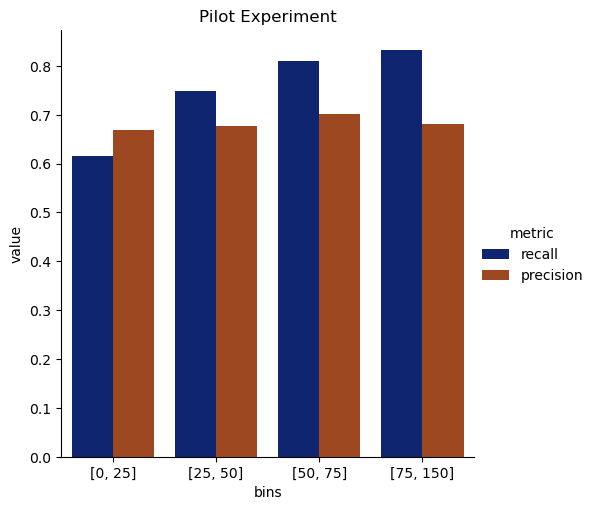

In [75]:
sns.catplot(
    data=df_pilot,
    kind='bar',
    x='bins',
    y='value',
    hue='metric',
    errorbar='sd',
    palette='dark'
)
plt.title('Pilot Experiment')
plt.show()

In [77]:
df_screen = pd.DataFrame(columns=['bins', 'metric', 'value'])
recall = []

for bounds in BIN_SIZE:
    print(f'Bin Size: {bounds}')
    
    for i in range(len(screen)):
        path = DIRECTORY + OUTPUT_DIR + screen[i]
        matches = np.load(path)
        matches = matches[:,:-1]

        imid = screen[i].split('.')[0]
        mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
        gti = skimage.morphology.label(mn_gt)
        gt_area = []
        
        for j in range(matches.shape[0]):
            label_gt = j + 1
            area = np.sum(gti == label_gt)
            gt_area.append(area)
            
        matches = np.column_stack((matches, gt_area))
        matches= matches[matches[:, -1].argsort()]

        bin_matches = matches[(matches[:, -1] > bounds[0]) & (matches[:, -1] < bounds[1])]
        f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:,:-1])
        recall.append(rec)
        
    
    d = {'bins': [str(bounds)], 'metric': ['recall'], 'value':[np.mean(recall)]}
    df = pd.DataFrame(data=d)
    df_screen = pd.concat([df_screen, df], ignore_index=True)
    print(f'(Average) Recall: {np.mean(recall):.2f}')
    
    
# Precision
precision = []
for bounds in BIN_SIZE:
    print(f'Bin Size: {bounds}')
    
    for i in range(len(screen)):
        path = DIRECTORY + OUTPUT_DIR + screen[i]
        matches = np.load(path)
        matches = matches[:,:-1]

        imid = screen[i].split('.')[0]
        prob_path = path.replace('_IoUs', '_probabilities')
        prob = np.load(prob_path)
        mn_pred = prob[0,:,:] > THRESHOLD
        pi = skimage.morphology.label(mn_pred)

        pred_area= []
        for j in range(matches.shape[1]): # along the columns
            label_pred = j + 1
            area = np.sum(pi == label_pred)
            pred_area.append(area)
            
        matches = np.row_stack((matches, pred_area))
        matches= matches[:, matches[-1, :].argsort()]


        bin_matches = matches[:, (matches[-1, :] > bounds[0]) & (matches[-1, :] < bounds[1])]
        f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:-1,:])
        precision.append(prec)
    
    d = {'bins': [str(bounds)], 'metric': ['precision'], 'value':[np.mean(precision)]}
    df = pd.DataFrame(data=d)
    df_screen = pd.concat([df_screen, df], ignore_index=True)
    print(f'(Average) Precision: {np.mean(precision):.2f}')

Bin Size: [0, 25]


/tmp/ipykernel_721877/563154595.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_screen = pd.concat([df_screen, df], ignore_index=True)


(Average) Recall: 0.59
Bin Size: [25, 50]
(Average) Recall: 0.76
Bin Size: [50, 75]
(Average) Recall: 0.83
Bin Size: [75, 150]
(Average) Recall: 0.87
Bin Size: [0, 25]
(Average) Precision: 0.74
Bin Size: [25, 50]
(Average) Precision: 0.80
Bin Size: [50, 75]
(Average) Precision: 0.82
Bin Size: [75, 150]
(Average) Precision: 0.85


In [ ]:
df_screen

# Visualization

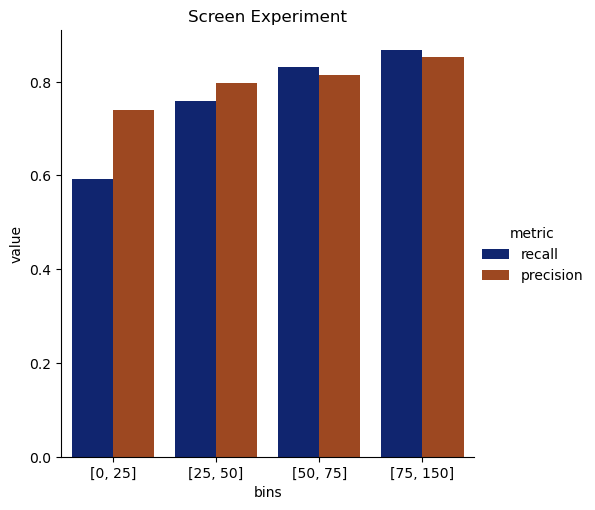

In [78]:
sns.catplot(
    data=df_screen,
    kind='bar',
    x='bins',
    y='value',
    hue='metric',
    errorbar='sd',
    palette='dark'
)
plt.title('Screen Experiment')
plt.show()